# Module 09: Statistical Visualization with Seaborn

Up to this point we have built every plot manually, specifying each axis, color, and marker explicitly. Seaborn is a library built on top of Matplotlib that provides higher-level functions designed specifically for statistical data: distributions, categorical comparisons, correlation matrices, and similar tasks that would require many lines of Matplotlib code to assemble from scratch. The tradeoff is that seaborn makes certain things very fast while making deep customization slightly less direct, so the two libraries are most useful together rather than as alternatives.

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. How seaborn relates to Matplotlib

Every seaborn plotting function returns a Matplotlib `Axes` object (or accepts one via the `ax` argument). This means you can pass an existing `ax` to a seaborn function and then keep modifying it with the same `ax.set_xlabel`, `ax.set_title`, and other methods you have been using throughout this course. Seaborn does not replace Matplotlib; it generates Matplotlib figures that you then control with all the tools you already know.

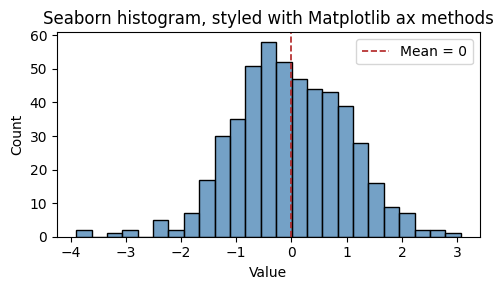

In [2]:
# A minimal example showing that a seaborn plot is just a Matplotlib axes
fig, ax = plt.subplots(figsize=(5, 3))

# Pass ax= so seaborn draws into our axes rather than creating its own figure
sns.histplot(np.random.default_rng(0).normal(0, 1, 500), ax=ax, color='steelblue', bins=25)

# These are plain Matplotlib axes methods — seaborn has not changed the interface
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.set_title('Seaborn histogram, styled with Matplotlib ax methods')
ax.axvline(0, color='firebrick', linewidth=1.2, linestyle='--', label='Mean = 0')
ax.legend()

plt.tight_layout()
plt.show()

The `ax=` argument is the key: it tells seaborn which axes to draw into, so the result slots into any figure layout you have already set up. After `sns.histplot` returns, the axes object is unchanged in type and the reference line and legend are added with unmodified Matplotlib calls.

## Synthetic polymer dataset

The plots in sections 2 through 7 all draw from the same dataset. It contains 60 synthetic polymer samples across three common commodity thermoplastics: polypropylene (PP), polyethylene (PE), and polystyrene (PS). Each row records the weight-average molecular weight, dispersity, glass transition temperature, tensile strength, and elongation at break. The value ranges are set to be physically realistic for each polymer type.

In [3]:
rng = np.random.default_rng(seed=42)
n_per_type = 20   # 20 samples per polymer type, 60 total

# PP: semi-crystalline, moderate Tg (around -10 to 5 C), high elongation
pp = pd.DataFrame({
    'polymer_type':     'PP',
    'Mw':               rng.normal(250_000, 40_000, n_per_type).clip(120_000, 400_000),
    'dispersity':       rng.normal(2.8, 0.4, n_per_type).clip(1.8, 4.2),
    'Tg':               rng.normal(-5, 4, n_per_type).clip(-18, 8),
    'tensile_strength': rng.normal(32, 4, n_per_type).clip(22, 42),
    'elongation':       rng.normal(400, 80, n_per_type).clip(180, 700),
})

# PE: semi-crystalline, very low Tg (around -120 C), very high elongation
pe = pd.DataFrame({
    'polymer_type':     'PE',
    'Mw':               rng.normal(180_000, 35_000, n_per_type).clip(80_000, 320_000),
    'dispersity':       rng.normal(3.5, 0.5, n_per_type).clip(2.0, 5.5),
    'Tg':               rng.normal(-120, 6, n_per_type).clip(-138, -102),
    'tensile_strength': rng.normal(25, 5, n_per_type).clip(12, 38),
    'elongation':       rng.normal(600, 100, n_per_type).clip(300, 900),
})

# PS: amorphous, high Tg (around 95 to 105 C), brittle (low elongation)
ps = pd.DataFrame({
    'polymer_type':     'PS',
    'Mw':               rng.normal(200_000, 30_000, n_per_type).clip(100_000, 320_000),
    'dispersity':       rng.normal(2.2, 0.3, n_per_type).clip(1.5, 3.2),
    'Tg':               rng.normal(100, 4, n_per_type).clip(88, 114),
    'tensile_strength': rng.normal(45, 5, n_per_type).clip(32, 60),
    'elongation':       rng.normal(3.5, 0.8, n_per_type).clip(1.5, 6.5),
})

polymer_df = pd.concat([pp, pe, ps], ignore_index=True)

# Round to sensible precision
polymer_df['Mw']               = polymer_df['Mw'].round(0).astype(int)
polymer_df['dispersity']       = polymer_df['dispersity'].round(2)
polymer_df['Tg']               = polymer_df['Tg'].round(1)
polymer_df['tensile_strength'] = polymer_df['tensile_strength'].round(1)
polymer_df['elongation']       = polymer_df['elongation'].round(1)

print(polymer_df.groupby('polymer_type')[['Tg','tensile_strength','elongation']].mean().round(1))
print(f'\nTotal rows: {len(polymer_df)}')

                 Tg  tensile_strength  elongation
polymer_type                                     
PE           -121.6              24.9       620.6
PP             -4.5              31.6       371.7
PS             99.8              46.1         3.3

Total rows: 60


The printed means confirm the expected physical ordering: PS has the highest Tg and tensile strength but the lowest elongation, PE has the lowest Tg and highest elongation, and PP sits between the two in most properties. This structure makes the dataset useful for demonstrating categorical comparisons.

## 2. `sns.scatterplot` and `sns.lineplot` with `hue` and `style`

The `hue` argument maps a column to point color, and `style` maps a column to marker shape. Together they let a single scatter plot carry three variables at once without any manual loop over groups. Seaborn handles the legend automatically.

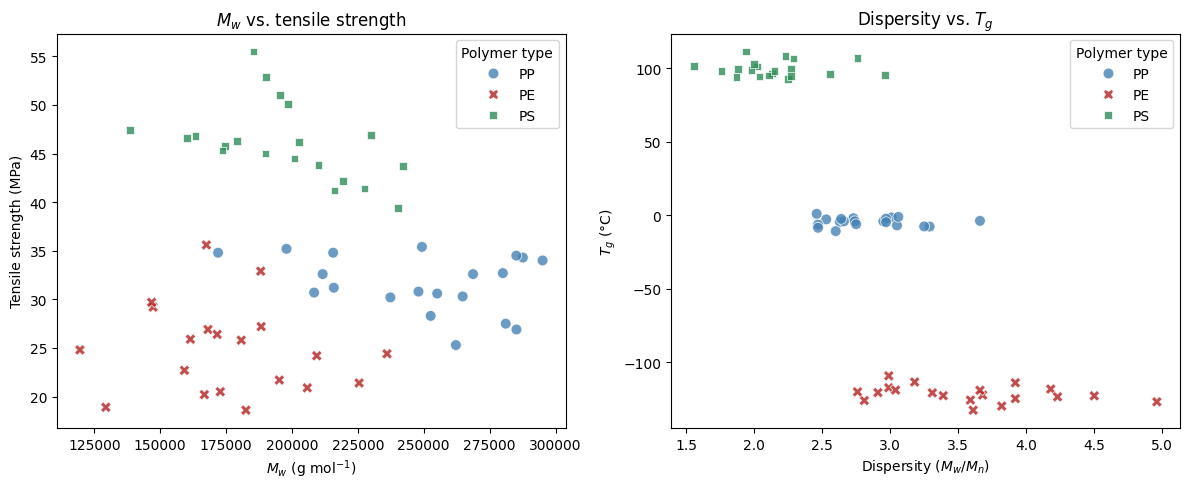

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Mw vs tensile strength, colored and shaped by polymer type
sns.scatterplot(
    data=polymer_df,
    x='Mw',
    y='tensile_strength',
    hue='polymer_type',
    style='polymer_type',
    palette={'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'},
    s=60,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_xlabel('$M_w$ (g mol$^{-1}$)')
axes[0].set_ylabel('Tensile strength (MPa)')
axes[0].set_title('$M_w$ vs. tensile strength')
axes[0].legend(title='Polymer type')

# Right: dispersity vs Tg
sns.scatterplot(
    data=polymer_df,
    x='dispersity',
    y='Tg',
    hue='polymer_type',
    style='polymer_type',
    palette={'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'},
    s=60,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_xlabel('Dispersity ($M_w / M_n$)')
axes[1].set_ylabel('$T_g$ (°C)')
axes[1].set_title('Dispersity vs. $T_g$')
axes[1].legend(title='Polymer type')

plt.tight_layout()
plt.show()

Both `hue` and `style` point to the same `polymer_type` column here, so each type gets a distinct color and a distinct marker. Using both encoding channels together means the plot remains interpretable even in greyscale print. The three types cluster cleanly in the Tg axis on the right panel because Tg is a near-constant material property, not a function of dispersity.

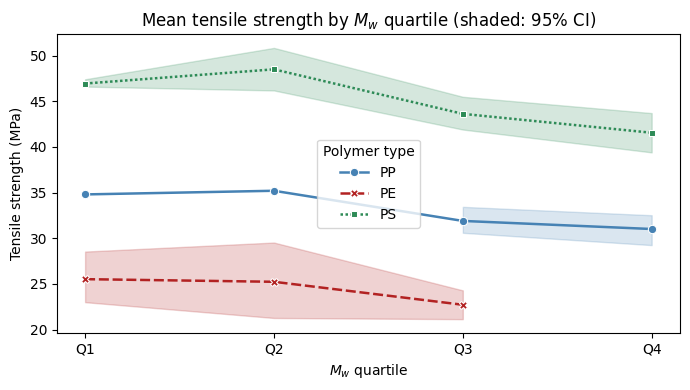

In [5]:
# sns.lineplot example: mean tensile strength as a function of Mw bins, per polymer type
# First, bin Mw into quartile groups within each polymer type
polymer_df['Mw_bin'] = pd.qcut(polymer_df['Mw'], q=4, labels=['Q1','Q2','Q3','Q4'])

fig, ax_line = plt.subplots(figsize=(7, 4))

# lineplot with hue draws one line per category and shades the 95% CI by default
sns.lineplot(
    data=polymer_df,
    x='Mw_bin',
    y='tensile_strength',
    hue='polymer_type',
    style='polymer_type',
    palette={'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'},
    markers=True,
    linewidth=1.8,
    ax=ax_line
)

ax_line.set_xlabel('$M_w$ quartile')
ax_line.set_ylabel('Tensile strength (MPa)')
ax_line.set_title('Mean tensile strength by $M_w$ quartile (shaded: 95% CI)')
ax_line.legend(title='Polymer type')

plt.tight_layout()
plt.show()

`sns.lineplot` computes the mean at each x position and draws a shaded confidence interval automatically. The shading width reflects how much the tensile strength varies within each Mw quartile bin, not measurement uncertainty. Because the synthetic data has no built-in Mw dependence for tensile strength, the lines are approximately flat, as expected.

## 3. `sns.histplot` and `sns.kdeplot`: comparing Tg distributions

`sns.histplot` with `kde=True` overlays a kernel density estimate on top of the histogram bars in a single call. This is useful when you want to see both the raw count data and a smoothed shape estimate together. The KDE line makes it easier to compare distribution shapes across groups without needing to match bin edges between groups.

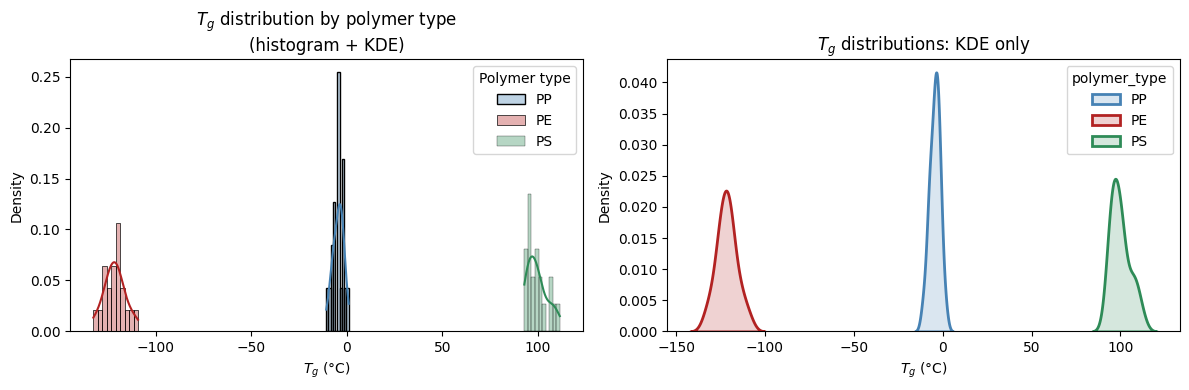

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram with KDE overlay, one panel per polymer type using hue
# stat='density' normalizes the histogram so the KDE and bars share the same y scale
for ptype, color in zip(['PP', 'PE', 'PS'], ['steelblue', 'firebrick', 'seagreen']):
    subset = polymer_df.loc[polymer_df['polymer_type'] == ptype, 'Tg']
    sns.histplot(
        subset,
        kde=True,
        stat='density',
        bins=10,
        color=color,
        alpha=0.35,
        label=ptype,
        ax=axes[0]
    )

axes[0].set_xlabel('$T_g$ (°C)')
axes[0].set_ylabel('Density')
axes[0].set_title('$T_g$ distribution by polymer type\n(histogram + KDE)')
axes[0].legend(title='Polymer type')

# Right: KDE curves only for a cleaner comparison of shape
sns.kdeplot(
    data=polymer_df,
    x='Tg',
    hue='polymer_type',
    palette={'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'},
    linewidth=2.0,
    fill=True,
    alpha=0.2,
    ax=axes[1]
)
axes[1].set_xlabel('$T_g$ (°C)')
axes[1].set_ylabel('Density')
axes[1].set_title('$T_g$ distributions: KDE only')

plt.tight_layout()
plt.show()

The three Tg distributions are completely separated in temperature, which reflects real polymer physics: PE is a polyolefin with a sub-ambient Tg around -120 °C, PP has a Tg near 0 °C, and PS is an amorphous glassy polymer with a Tg near 100 °C. Using `stat='density'` on the left panel is important when overlaying a KDE: it puts the histogram and the KDE on the same y scale so the curve sits on top of the bars rather than appearing to float at a different level.

## 4. `sns.boxplot` and `sns.violinplot`: tensile strength distributions

Box plots and violin plots are both designed to show how a continuous variable is distributed across categorical groups. A box plot encodes the median, interquartile range, and outliers explicitly. A violin plot adds a kernel density estimate mirrored on both sides, which shows the full shape of the distribution, including multimodality, that a box plot would hide.

C:\Users\Kiarash\AppData\Local\Temp\ipykernel_9660\3328466373.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Kiarash\AppData\Local\Temp\ipykernel_9660\3328466373.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Kiarash\AppData\Local\Temp\ipykernel_9660\3328466373.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


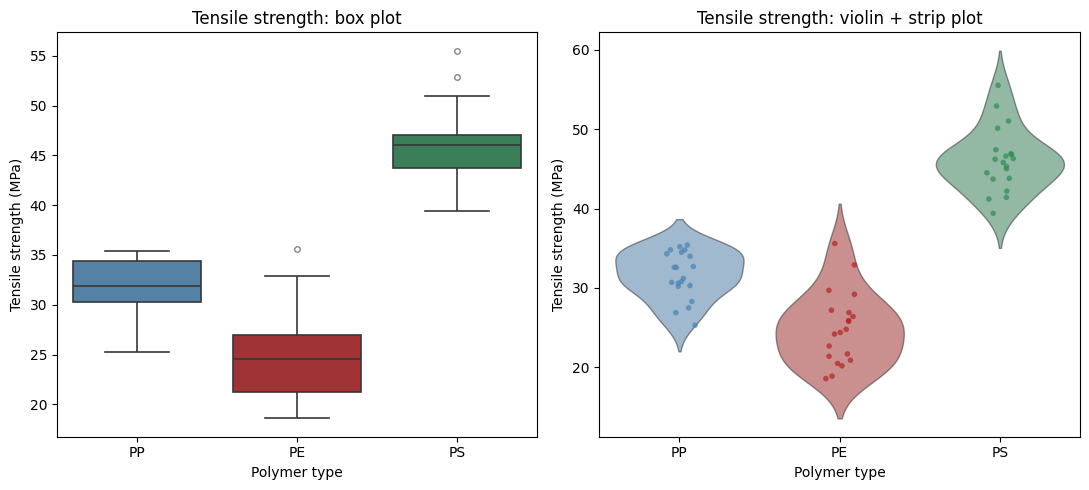

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
palette = {'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'}

# Left: box plot
sns.boxplot(
    data=polymer_df,
    x='polymer_type',
    y='tensile_strength',
    palette=palette,
    linewidth=1.2,
    flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.6},
    ax=axes[0]
)
axes[0].set_xlabel('Polymer type')
axes[0].set_ylabel('Tensile strength (MPa)')
axes[0].set_title('Tensile strength: box plot')

# Right: violin plot with individual data points overlaid
sns.violinplot(
    data=polymer_df,
    x='polymer_type',
    y='tensile_strength',
    palette=palette,
    inner=None,           # remove the inner box so we can overlay raw points cleanly
    linewidth=1.0,
    alpha=0.55,
    ax=axes[1]
)
# Strip plot overlays individual observations on top of the violin
sns.stripplot(
    data=polymer_df,
    x='polymer_type',
    y='tensile_strength',
    palette=palette,
    size=4,
    jitter=True,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_xlabel('Polymer type')
axes[1].set_ylabel('Tensile strength (MPa)')
axes[1].set_title('Tensile strength: violin + strip plot')

plt.tight_layout()
plt.show()

PS has the highest median tensile strength and the narrowest spread, consistent with it being a stiff, relatively homogeneous glassy polymer. PE has the widest distribution, reflecting the greater sensitivity of PE mechanical properties to molecular weight and crystallinity. Overlaying the strip plot on the violin shows every individual data point alongside the density shape, which is good practice with small datasets: it prevents the violin from implying more statistical certainty than the sample size justifies.

## 5. `sns.jointplot`: parity plot for a Tg prediction model

A parity plot (predicted vs. true values) is one of the most common validation figures in machine learning applied to materials science. The ideal model places all points on the diagonal line y = x. Deviations above the line indicate over-prediction; deviations below indicate under-prediction. `sns.jointplot` is a natural fit here because it places the scatter on the central panel and shows the marginal distributions of the prediction errors on the sides, giving a complete picture of model performance in a single figure.

In [8]:
rng_ml = np.random.default_rng(seed=11)
n_train, n_test = 250, 50

# True Tg values drawn from a realistic range for a mixed polymer dataset
tg_true_train = rng_ml.uniform(-130, 120, n_train)
tg_true_test  = rng_ml.uniform(-130, 120, n_test)

# Model predictions: true value plus noise; test set has slightly larger error
tg_pred_train = tg_true_train + rng_ml.normal(0, 6,  n_train)
tg_pred_test  = tg_true_test  + rng_ml.normal(2, 12, n_test)   # small positive bias on test

parity_df = pd.DataFrame({
    'Tg_true':  np.concatenate([tg_true_train, tg_true_test]),
    'Tg_pred':  np.concatenate([tg_pred_train, tg_pred_test]),
    'split':    ['Train'] * n_train + ['Test'] * n_test,
})

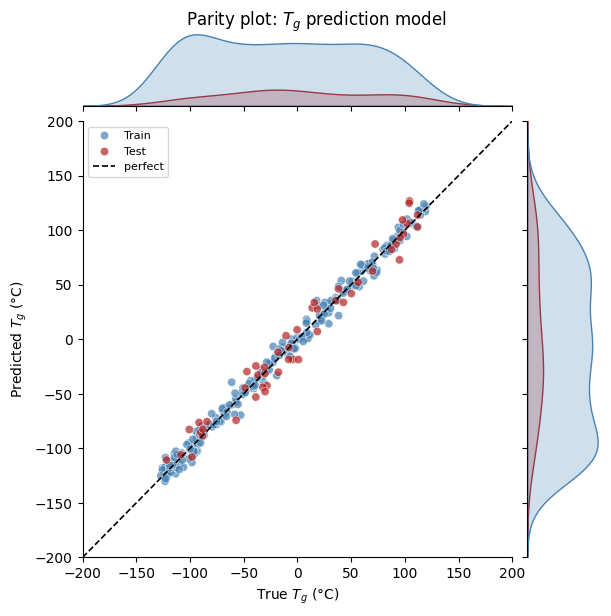

In [9]:
# jointplot creates its own figure; pass height to control size
g = sns.jointplot(
    data=parity_df,
    x='Tg_true',
    y='Tg_pred',
    hue='split',
    palette={'Train': 'steelblue', 'Test': 'firebrick'},
    alpha=0.7,
    height=6,
    marginal_kws={'fill': True, 'alpha': 0.25}  # KDE on the marginal axes
)

# Access the central axes through g.ax_joint and add a diagonal reference line
lims = [-200, 200]
g.ax_joint.plot(lims, lims, color='black', linewidth=1.2, linestyle='--', label='perfect')
g.ax_joint.set_xlim(lims)
g.ax_joint.set_ylim(lims)

g.ax_joint.set_xlabel('True $T_g$ (°C)')
g.ax_joint.set_ylabel('Predicted $T_g$ (°C)')
g.ax_joint.legend(fontsize=8, loc='upper left')

# Add an overall title via the underlying figure object
g.figure.suptitle('Parity plot: $T_g$ prediction model', y=1.01)

plt.show()

`sns.jointplot` returns a `JointGrid` object rather than a plain axes. The central scatter is at `g.ax_joint`, and the two marginal axes are at `g.ax_marg_x` and `g.ax_marg_y`. Adding the diagonal line to `g.ax_joint` is just a standard `ax.plot` call. The marginal KDEs show the distribution of true and predicted values separately: if the model is unbiased, the two marginals should overlap. Here the test set marginal is slightly shifted upward, reflecting the positive bias added to the synthetic test predictions.

## 6. `sns.heatmap`: correlation matrix

A correlation matrix shows the Pearson correlation coefficient between every pair of numeric columns. Values near 1 indicate strong positive correlation, values near -1 indicate strong negative correlation, and values near 0 indicate no linear relationship. `sns.heatmap` renders a DataFrame as a color-coded grid and can annotate each cell with its numeric value.

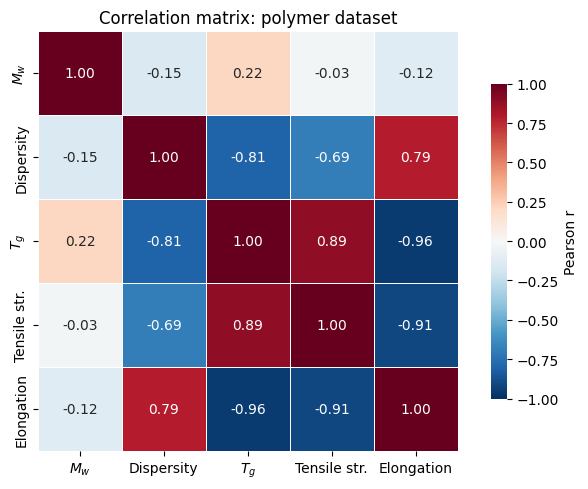

In [10]:
# Select the numeric columns for the correlation calculation
numeric_cols = ['Mw', 'dispersity', 'Tg', 'tensile_strength', 'elongation']
corr_matrix = polymer_df[numeric_cols].corr()

# Nicer column labels for the plot
label_map = {
    'Mw': '$M_w$',
    'dispersity': 'Dispersity',
    'Tg': '$T_g$',
    'tensile_strength': 'Tensile str.',
    'elongation': 'Elongation'
}
corr_display = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax_hm = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_display,
    ax=ax_hm,
    annot=True,           # print the correlation value in each cell
    fmt='.2f',            # two decimal places
    cmap='RdBu_r',        # diverging colormap: red = positive, blue = negative
    vmin=-1, vmax=1,      # fix the color scale to the full [-1, 1] range
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
)

ax_hm.set_title('Correlation matrix: polymer dataset')
plt.tight_layout()
plt.show()

The strongest correlations in this dataset are structural: Tg is strongly correlated with tensile strength (polymers with higher Tg tend to be stiffer and stronger at room temperature) and strongly anti-correlated with elongation (glassy polymers above their Tg are brittle). These are not coincidences of the synthetic data; they reflect the same underlying structure-property relationship across the three polymer types, which differ enough in Tg that the between-group variance dominates the correlation signal.

## 7. `sns.pairplot`: all pairwise relationships at once

`sns.pairplot` creates a grid of scatter plots for every pair of numeric columns, with distribution plots along the diagonal. It is the fastest way to get a broad overview of a new dataset and spot any obvious relationships, outliers, or grouping structure before committing to specific analyses.

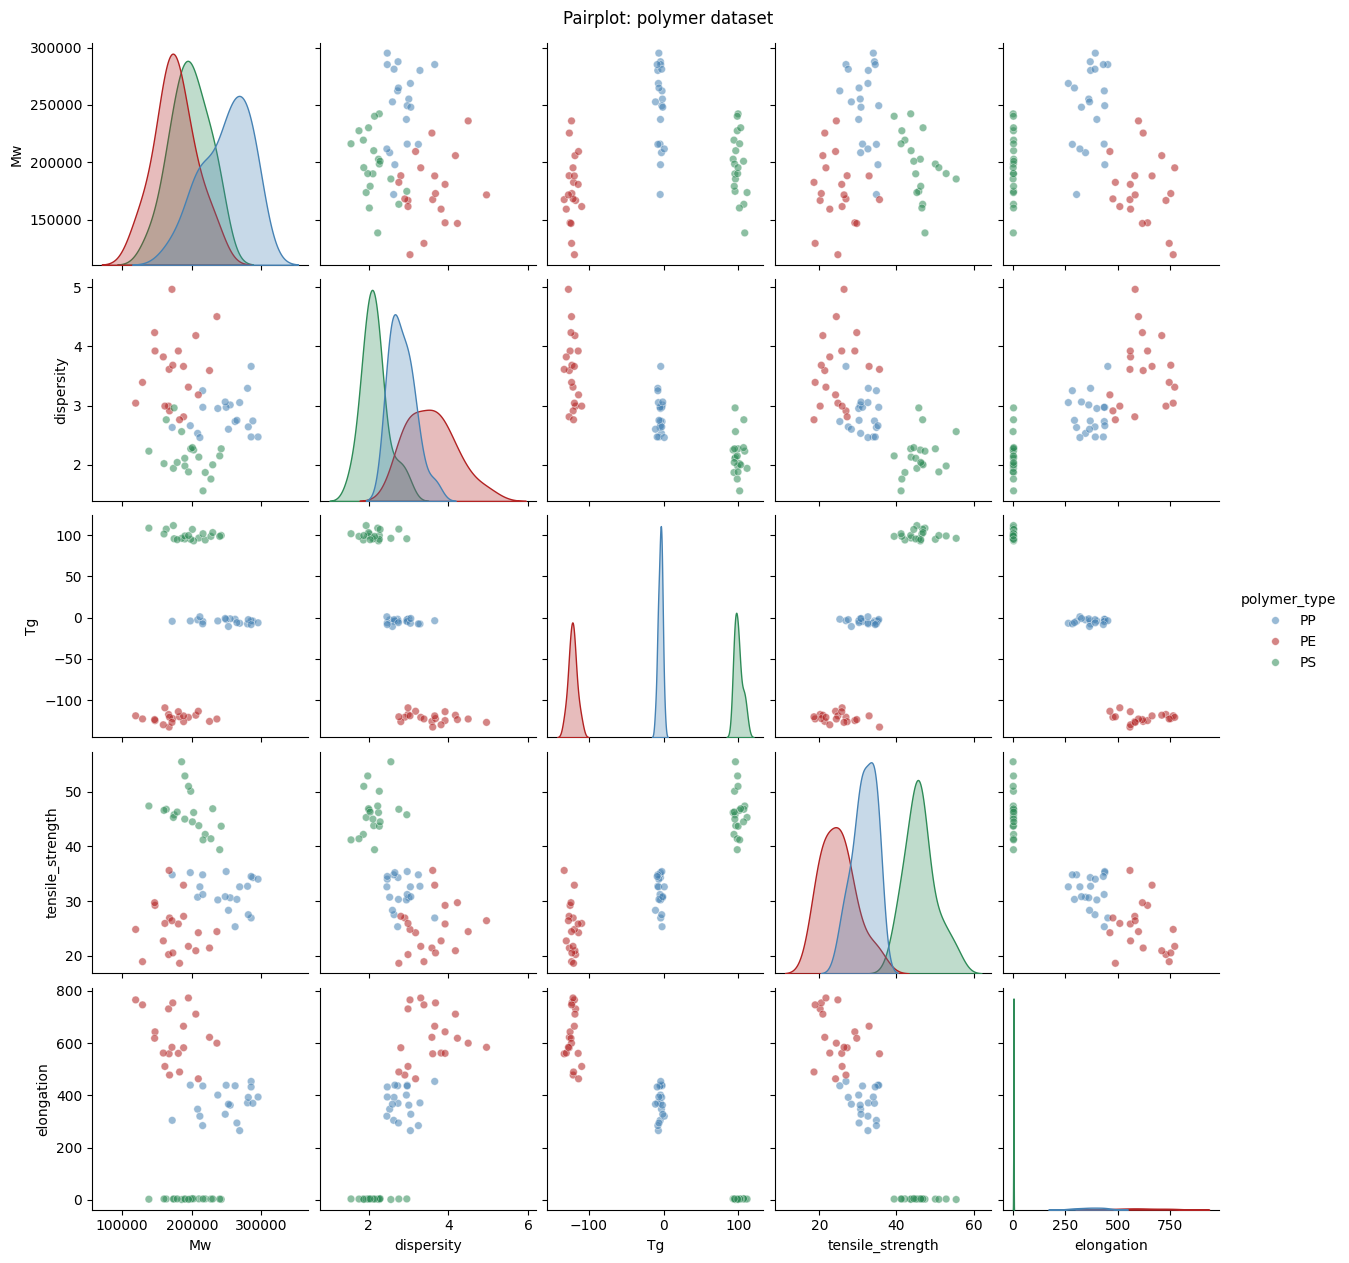

In [11]:
pair_cols = ['Mw', 'dispersity', 'Tg', 'tensile_strength', 'elongation', 'polymer_type']

g_pair = sns.pairplot(
    polymer_df[pair_cols],
    hue='polymer_type',
    palette={'PP': 'steelblue', 'PE': 'firebrick', 'PS': 'seagreen'},
    diag_kind='kde',       # KDE on the diagonal instead of a histogram
    plot_kws={'alpha': 0.55, 's': 30},
    diag_kws={'fill': True, 'alpha': 0.3}
)

g_pair.figure.suptitle('Pairplot: polymer dataset', y=1.01)
plt.show()

Pairplot is an exploratory tool, not a presentation tool. The grid here is 5x5 panels, which is already at the limit of what a reader can absorb in a single figure. For a journal paper you would identify the one or two panels that carry the scientific message and build those as standalone figures with proper axis labels, consistent sizing, and publication-appropriate styling. The pairplot is what you use to decide which panels those are.

## Seaborn in perspective

Seaborn is excellent for statistical exploration and for specific plot types (distributions, categorical comparisons, correlation heatmaps, pairwise grids) where its defaults produce clean, informative results with very little code. When you move toward publication, you will often find that fine-grained control over spacing, tick positions, font sizes, color choices, and panel arrangement is easier to achieve by dropping back to Matplotlib directly, or by using Matplotlib methods on the axes that seaborn returns. The two approaches are not in conflict: use seaborn to get a working figure quickly, then refine it with Matplotlib until it meets the standards of the target journal or presentation.